Total rows: 78

Status:
status
OK        69
FAILED     9
Name: count, dtype: int64

Successful fits: 69
Valid fits: 69

Theta [mas]
count    69.000000
mean      2.443197
std       4.738222
min       0.022034
25%       0.342483
50%       1.141365
75%       2.202799
max      35.137866
Name: theta_mas, dtype: float64

Tb [K]
count    6.900000e+01
mean     1.251228e+12
std      3.073485e+12
min      2.224043e+07
25%      1.398512e+10
50%      1.306067e+11
75%      8.512122e+11
max      1.662467e+13
Name: Tb_K, dtype: float64


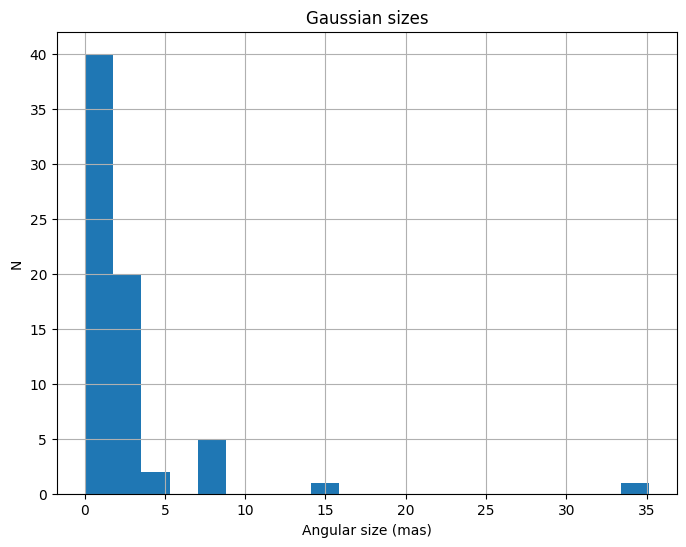

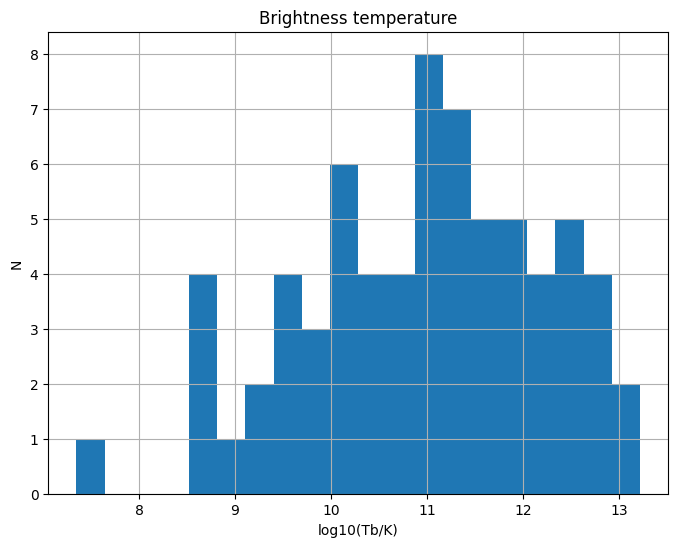

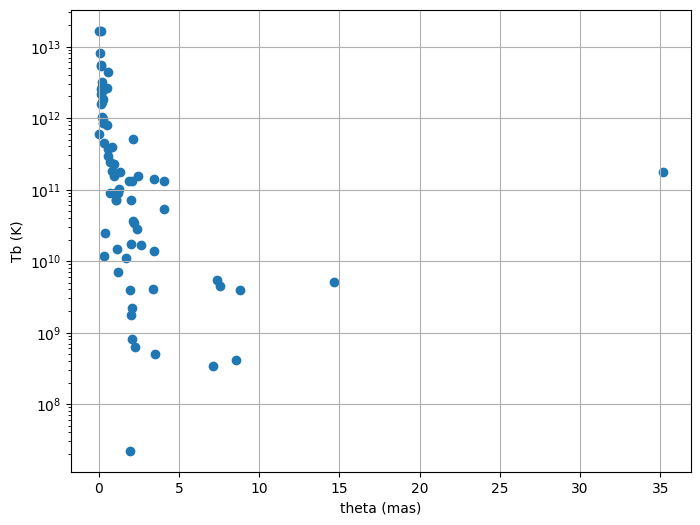


By band
      theta_mas          Tb_K
band                         
C      0.908088  1.813777e+11
K      1.982790  3.068451e+09
L      2.058337  1.526293e+11

By mode
             theta_mas          Tb_K
mode                                
GVLBI         2.160411  4.288451e+09
RADIOASTRON   0.856178  1.785275e+11

Smallest sizes


,session,date,band,theta_mas,theta_mas_err,Tb_K
25,RAKS08JQ,20141214T080000,K,0.022034,35.501412,1.662467e+13
41,RAKS12SY,20160329T010000,K,0.038494,19.839462,5.997663e+11
24,RAKS08JQ,20141214T080000,C,0.087230,0.424066,8.020246e+12
46,RAKS12UX,20160419T190000,C,0.123376,1.485600,5.530068e+12
30,RAKS08UR,20150403T220000,C,0.137115,5.849563,1.660502e+13
27,RAKS08TO,20150327T001000,C,0.138758,46.254241,5.380202e+12
10,RAES03RO,20130422T172000,C,0.157159,102.494663,2.543204e+12
18,RAKS01XX,20140403T010000,C,0.169777,102.787096,2.133224e+12
49,RAKS12VC,20160424T140000,C,0.181758,0.393380,1.581208e+12
36,RAKS12HX,20151201T040000,C,0.190828,0.507698,1.695531e+12



Highest Tb


,session,date,band,theta_mas,theta_mas_err,Tb_K
25,RAKS08JQ,20141214T080000,K,0.022034,35.501412,1.662467e+13
30,RAKS08UR,20150403T220000,C,0.137115,5.849563,1.660502e+13
24,RAKS08JQ,20141214T080000,C,0.087230,0.424066,8.020246e+12
46,RAKS12UX,20160419T190000,C,0.123376,1.485600,5.530068e+12
27,RAKS08TO,20150327T001000,C,0.138758,46.254241,5.380202e+12
62,RAKS18EH,20171111T102000,L,0.616675,4.743985,4.345194e+12
5,RAES03Q,20120405T170000,C,0.237506,2.742675,3.146771e+12
26,RAKS08JV,20141215T210000,C,0.205030,0.307077,2.844494e+12
45,RAKS12UO,20160414T230000,L,0.529269,7.296259,2.623809e+12
10,RAES03RO,20130422T172000,C,0.157159,102.494663,2.543204e+12


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV = "gaussian_fits/gaussian_fit_log.csv"

df = pd.read_csv(CSV)

print("Total rows:", len(df))

print("\nStatus:")
print(df["status"].value_counts())

# ----------------------------------------
# только успешные фиты
# ----------------------------------------

ok = df[df.status == "OK"].copy()

print("\nSuccessful fits:", len(ok))

# ----------------------------------------
# очистка
# ----------------------------------------

ok = ok.replace(
    [np.inf, -np.inf],
    np.nan
)

ok = ok.dropna(
    subset=[
        "theta_mas",
        "Tb_K"
    ]
)

print("Valid fits:", len(ok))

# ----------------------------------------
# статистика
# ----------------------------------------

print("\nTheta [mas]")

print(
    ok["theta_mas"].describe()
)

print("\nTb [K]")

print(
    ok["Tb_K"].describe()
)

# ----------------------------------------
# histogram theta
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.hist(
    ok["theta_mas"],
    bins=20
)

plt.xlabel("Angular size (mas)")
plt.ylabel("N")

plt.title("Gaussian sizes")

plt.grid()

plt.show()

# ----------------------------------------
# histogram Tb
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.hist(
    np.log10(ok["Tb_K"]),
    bins=20
)

plt.xlabel("log10(Tb/K)")
plt.ylabel("N")

plt.title("Brightness temperature")

plt.grid()

plt.show()

# ----------------------------------------
# theta vs Tb
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    ok["theta_mas"],
    ok["Tb_K"]
)

plt.yscale("log")

plt.xlabel("theta (mas)")
plt.ylabel("Tb (K)")

plt.grid()

plt.show()

# ----------------------------------------
# by band
# ----------------------------------------

print("\nBy band")

print(
    ok.groupby("band")[
        ["theta_mas", "Tb_K"]
    ].median()
)

# ----------------------------------------
# by mode
# ----------------------------------------

print("\nBy mode")

print(
    ok.groupby("mode")[
        ["theta_mas", "Tb_K"]
    ].median()
)

# ----------------------------------------
# compact epochs
# ----------------------------------------

print("\nSmallest sizes")

display(

    ok.sort_values(
        "theta_mas"
    )[
        [
            "session",
            "date",
            "band",
            "theta_mas",
            "theta_mas_err",  # добавлено
            "Tb_K"
        ]
    ].head(20)

)

# ----------------------------------------
# hottest epochs
# ----------------------------------------

print("\nHighest Tb")

display(

    ok.sort_values(
        "Tb_K",
        ascending=False
    )[
        [
            "session",
            "date",
            "band",
            "theta_mas",
            "theta_mas_err",
            "Tb_K"
        ]
    ].head(20)

)

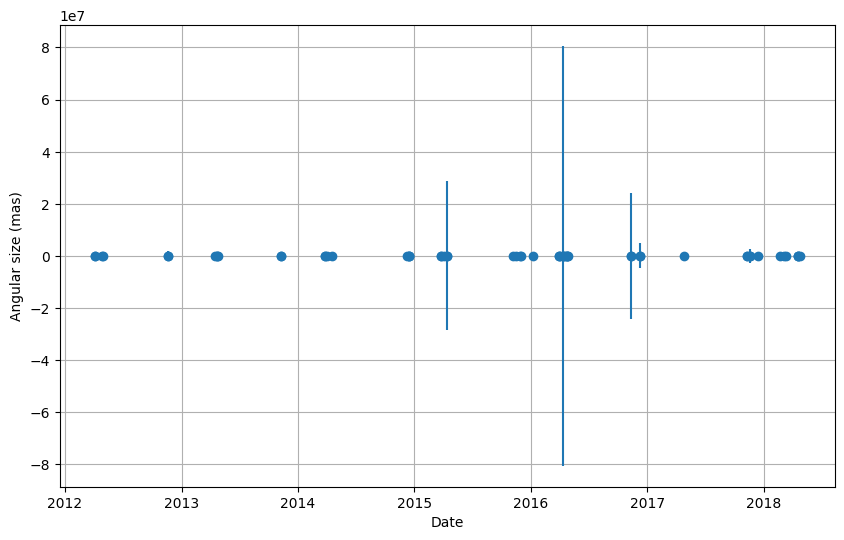

In [42]:
ra = ok[
    ok["mode"] == "RADIOASTRON"
]

plt.figure(figsize=(10,6))

plt.errorbar(
    pd.to_datetime(
        ra["date"].str[:8],  # берем только первые 8 символов (дату)
        format="%Y%m%d"
    ),
    ra["theta_mas"],
    yerr=ra["theta_mas_err"],
    fmt="o"
)

plt.xlabel("Date")
plt.ylabel("Angular size (mas)")
plt.grid()

plt.show()